In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from setup import train, device, train_test_split_path, accuracy, plot_losses, Sequence_dataset, get_data_max, train_pro_max
X_train_path, X_test_path, X_eval_path, y_train, y_test, y_eval = train_test_split_path()
import gc

Usando dispositivo: cuda


In [2]:
# Parametros en general por limitaciones de hardware
BATCH_SIZES = {
    'mel': 16,
    'mfcc': 32,
    'cqt': 32,
    'wav2vec2': 28,
    'EnCodecMAE': 64
}

LEARNING_RATES = {
    'mel': 0.001,
    'mfcc': 0.001,
    'cqt': 0.001,
    'wav2vec2': 0.0001,
    'EnCodecMAE': 0.001
}

### Modelo 1

In [3]:
class classf(nn.Module):
    def __init__(self, hidden_dim, feat_dim=768, nhead=4):
        super().__init__()
        # feat_dim is the dimensionality of each time‑step embedding
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=feat_dim,
                batch_first=True,
                nhead=nhead, 
                dim_feedforward=hidden_dim
            ),
            num_layers=1
        )

        self.attn = nn.Linear(feat_dim, 1)
        self.Linear = nn.Linear(in_features=feat_dim, out_features=10)

    def forward(self, input_seq):
        # input_seq: (batch, time, features)
        out = self.transformer(input_seq)
        # attention
        attn_weights = torch.softmax(self.attn(out).squeeze(-1), dim=1)  # (batch, time)
        context = torch.sum(out * attn_weights.unsqueeze(-1), dim=1)     # (batch, feat_dim)
        outputs = self.Linear(context)
        return outputs


In [4]:
# Definimos hiperparámetros
NUM_EPOCHS = {
    'mel': 30,
    'cqt': 30,
    'mfcc': 30,
    'wav2vec2': 20,
    'EnCodecMAE': 35
}
params = {
    'num_epoths': NUM_EPOCHS,
    'batch_sizes': BATCH_SIZES,
    'learning_rates': LEARNING_RATES,
    'hidden_dim': 16
}

train_losses, test_losses, accur = {}, {}, {} # PARA EL SUMMARY

In [5]:
MODEL = classf
for FEATURE in ['cqt','mfcc', 'wav2vec2','EnCodecMAE']:
    train_dataset, test_dataset = get_data_max(FEATURE, Sequence_dataset)
    params['feat_dim'] = train_dataset[1]['input_length'][1] # depende del dataset

    # Entrenamos el modelo
    model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
        model_class=MODEL,
        train_dataset=train_dataset,
        test_dataset=test_dataset,
        feature_name=FEATURE, 
        **params
    )
    accur[FEATURE] = accuracy(model0, test_dataset)
    del train_dataset, test_dataset, model0
    torch.cuda.empty_cache()
    gc.collect()

Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[-28.6540, -23.5845, -20.2321,  ..., -46.4007, -45.0566, -46.1026],
        [-27.9601, -22.4260, -18.8270,  ..., -34.6097, -32.9693, -34.7625],
        [-27.5905, -21.5936, -17.8161,  ..., -42.5703, -45.5733, -51.2996],
        ...,
        [-71.7345, -73.9189, -80.0000,  ..., -42.2461, -42.9362, -42.7572],
        [-71.6110, -74.3702, -80.0000,  ..., -39.9783, -40.0139, -53.5620],
        [-71.9175, -74.8183, -80.0000,  ..., -50.7851, -42.2692, -45.5680]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (1290, 84), 'target_length': 10}
--------------------------------------------------
Modelo creado con 32619 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/30
  P

#### Summary plot

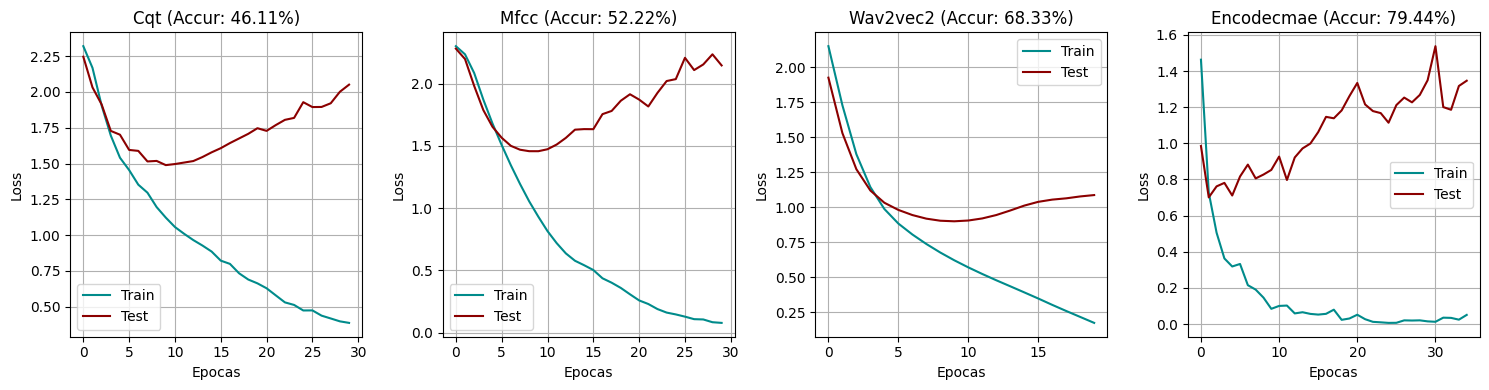

In [7]:
fig, axes = plt.subplots(1, len(train_losses.keys()), figsize=(15, 4))

for i, feat in enumerate(train_losses.keys()):
    plot_losses(train_losses[feat], test_losses[feat], axes[i], title=feat.capitalize(), accuracy=accur[feat])
#for ax in axes:
#    ax.set_ylim(-0.1, 2.5)
plt.tight_layout()
plt.show()

### Modelo 2
idem modelo 1 per nhead 12 y solo para cqt y mfcc que no son embeddins

In [ ]:
# Definimos hiperparámetros
NUM_EPOCHS = {
    'mel': 30,
    'cqt': 30,
    'mfcc': 30,
    'wav2vec2': 20,
    'EnCodecMAE': 35
}
params = {
    'num_epoths': NUM_EPOCHS,
    'batch_sizes': BATCH_SIZES,
    'learning_rates': LEARNING_RATES,
    'hidden_dim': 16,
    'nhead': 12
}

train_losses, test_losses, accur = {}, {}, {} # PARA EL SUMMARY

In [5]:
MODEL = classf
for FEATURE in ['cqt','mfcc']:
    train_dataset, test_dataset = get_data_max(FEATURE, Sequence_dataset)
    params['feat_dim'] = train_dataset[1]['input_length'][1] # depende del dataset

    # Entrenamos el modelo
    model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
        model_class=MODEL,
        train_dataset=train_dataset,
        test_dataset=test_dataset,
        feature_name=FEATURE, 
        **params
    )
    accur[FEATURE] = accuracy(model0, test_dataset)
    del train_dataset, test_dataset, model0
    torch.cuda.empty_cache()
    gc.collect()

Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[-28.6540, -23.5845, -20.2321,  ..., -46.4007, -45.0566, -46.1026],
        [-27.9601, -22.4260, -18.8270,  ..., -34.6097, -32.9693, -34.7625],
        [-27.5905, -21.5936, -17.8161,  ..., -42.5703, -45.5733, -51.2996],
        ...,
        [-71.7345, -73.9189, -80.0000,  ..., -42.2461, -42.9362, -42.7572],
        [-71.6110, -74.3702, -80.0000,  ..., -39.9783, -40.0139, -53.5620],
        [-71.9175, -74.8183, -80.0000,  ..., -50.7851, -42.2692, -45.5680]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (1290, 84), 'target_length': 10}
--------------------------------------------------
Modelo creado con 32619 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/30
  P

#### Summary plot

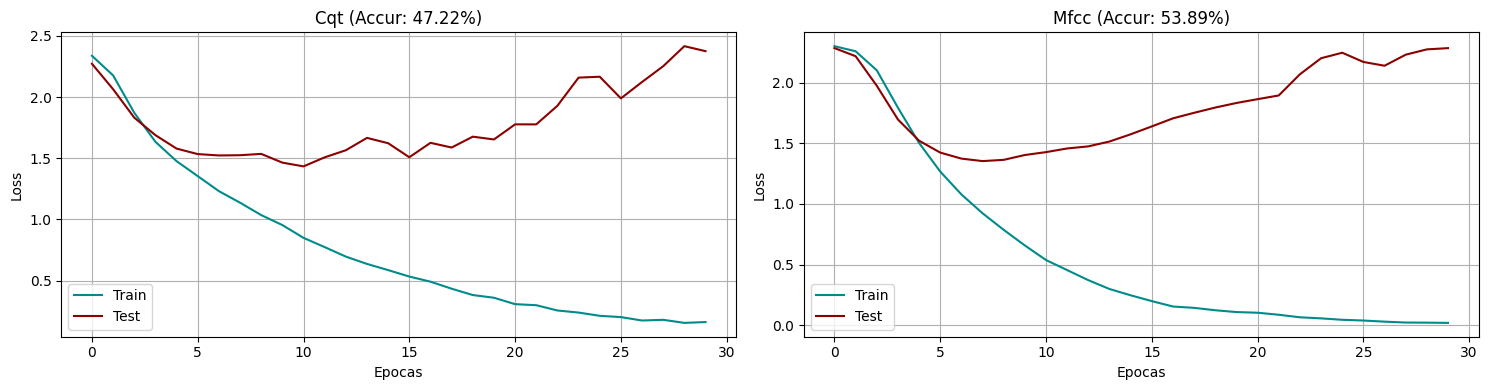

In [6]:
fig, axes = plt.subplots(1, len(train_losses.keys()), figsize=(15, 4))

for i, feat in enumerate(train_losses.keys()):
    plot_losses(train_losses[feat], test_losses[feat], axes[i], title=feat.capitalize(), accuracy=accur[feat])
#for ax in axes:
#    ax.set_ylim(-0.1, 2.5)
plt.tight_layout()
plt.show()